# Step 1-C: Pricing the Asian option using Monte Carlo simulation under the Heston (1993) model, calibrated using the Carr and Madan (1999) approach.

In [45]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + 
                         np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

In [55]:
def Heston_paths(S0, r, v, row, cho_matrix, dt):
    M, I = v.shape
    M = M - 1
    S = np.zeros((M + 1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t]) * dt + 
                                np.sqrt(v[t]) * ran[row] * sdt)
    return S

In [56]:
def random_number_gen(M, I):
    return np.random.standard_normal((2, M + 1, I))

In [57]:
def plot_paths(S, V, n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price Paths")
    ax1.set_ylabel("Price ($)")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V)), V[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility Paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")
    plt.show()

In [58]:
def heston_asian_call_mc(S, K, r, T):
    """Asian call pricing - arithmetic average over entire path"""
    # Calculate average price over the entire path (including S0)
    average_price = np.mean(S, axis=0)
    payoff = np.maximum(0, average_price - K)
    average_payoff = np.mean(payoff)
    return np.exp(-r * T) * average_payoff

In [59]:
# Calibrated Heston parameters
kappa = 2.033527    # Kappa (κ) - mean reversion speed
theta = 0.069957    # Theta (θ) - long-term variance
sigma = 0.533399    # Sigma (σ) - volatility of volatility
rho = -0.775616     # Rho (ρ) - correlation between price and volatility
v0 = 0.103354       # V0 (v₀) - initial variance

# Market parameters
S0 = 232.90         # Current SM Energy Company stock price
r = 0.015            # Risk-free rate (adjust based on market data)
K = S0              # ATM (At-the-Money) strike

In [90]:
# Asian option parameters
T = 20/250          # 20 days in years (250 trading days per year)
M0 = 252            # Number of time steps per year
M = int(M0 * T)     # Total time steps
I = 200000          # Number of simulations (increased for better accuracy)

dt = T / M          # Time step length

In [91]:
print("Simulation Parameters:")
print(f"S0: ${S0}, K: ${K}, T: {T:.4f} years ({T*252:.0f} days)")
print(f"M: {M} time steps, I: {I} simulations")
print(f"Heston Parameters: κ={kappa}, θ={theta}, σ={sigma}, ρ={rho}, v0={v0}")

Simulation Parameters:
S0: $232.9, K: $232.9, T: 0.0800 years (20 days)
M: 20 time steps, I: 200000 simulations
Heston Parameters: κ=2.033527, θ=0.069957, σ=0.533399, ρ=-0.775616, v0=0.103354


In [92]:
# Random number generation
np.random.seed(2025)  # For reproducibility
rand = random_number_gen(M, I)

# Covariance matrix
covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho]
covariance_matrix[1] = [rho, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

In [93]:
# Simulate volatility paths
print("\nSimulating volatility paths...")
V = SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, 1, cho_matrix)

# Simulate price paths
print("Simulating price paths...")
S = Heston_paths(S0, r, V, 0, cho_matrix, dt)

# Option pricing
print("\nCalculating prices...")
# Asian Call
asian_price = heston_asian_call_mc(S, K, r, T)
print(f"Asian ATM call price: ${asian_price:.4f}")



Simulating volatility paths...
Simulating price paths...

Calculating prices...
Asian ATM call price: $3.8351


In [85]:
# Apply 4% bank fee
bank_fee_rate = 0.04
final_price = asian_price * (1 + bank_fee_rate)

print(f"\n=== FINAL RESULTS ===")
print(f"Theoretical Asian option price: ${asian_price:.4f}")
print(f"Bank fee (4%): ${asian_price * bank_fee_rate:.4f}")
print(f"Final price for client: ${final_price:.4f}")


=== FINAL RESULTS ===
Theoretical Asian option price: $3.8241
Bank fee (4%): $0.1530
Final price for client: $3.9771



Generating plots...


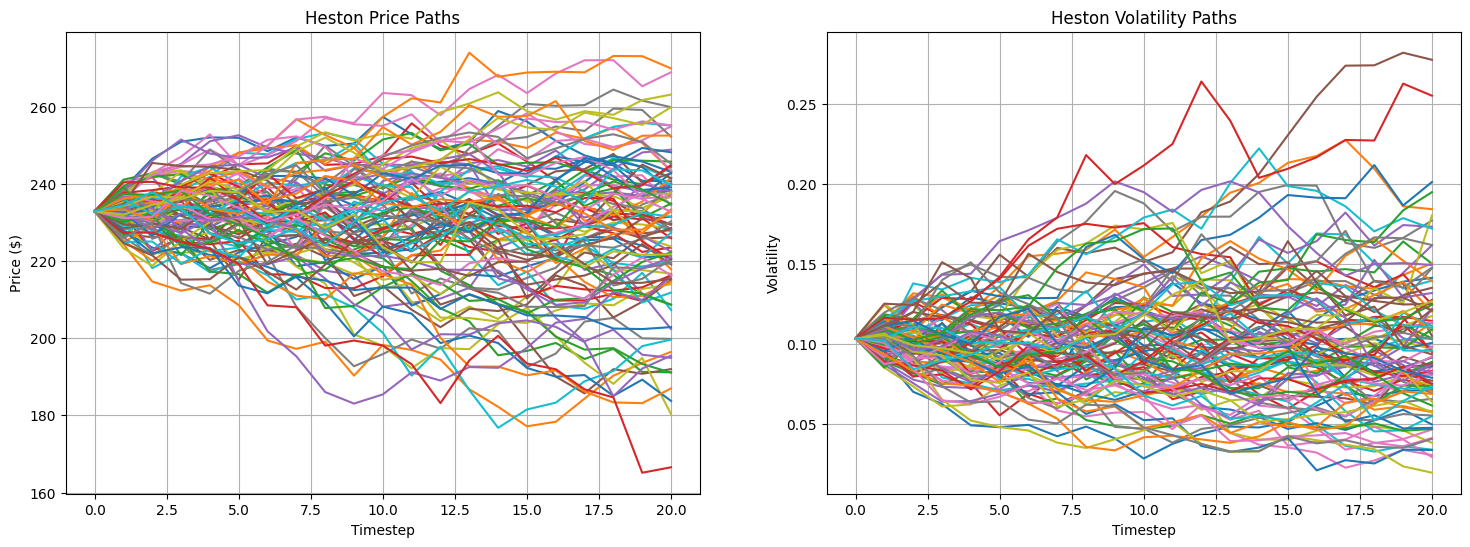

In [86]:
# Plot some sample paths
print("\nGenerating plots...")
plot_paths(S, V, 100)

In [87]:
# Statistical analysis
print("\n=== STATISTICAL ANALYSIS ===")
final_prices = S[-1, :]
average_prices = np.mean(S, axis=0)

print(f"Average final price: ${np.mean(final_prices):.2f}")
print(f"Average arithmetic mean price: ${np.mean(average_prices):.2f}")
print(f"Average final volatility: {np.mean(np.sqrt(V[-1, :])):.4f}")
print(f"Average Asian payoff: {np.mean(np.maximum(0, average_prices - K)):.4f}")


=== STATISTICAL ANALYSIS ===
Average final price: $229.34
Average arithmetic mean price: $231.12
Average final volatility: 0.3054
Average Asian payoff: 3.8287


In [88]:
# Confidence interval for Asian price
payoffs = np.maximum(0, average_prices - K)
asian_payoffs_discounted = np.exp(-r * T) * payoffs
std_error = np.std(asian_payoffs_discounted) / np.sqrt(I)
confidence_interval = 1.96 * std_error # 95% confidence

print(f"\nMonte Carlo estimation precision:")
print(f"Standard error: {std_error:.6f}")
print(f"95% Confidence interval: [${asian_price - confidence_interval:.4f}, ${asian_price + confidence_interval:.4f}]")


Monte Carlo estimation precision:
Standard error: 0.013232
95% Confidence interval: [$3.7982, $3.8501]


In [89]:
# Simulation quality check
print(f"\n=== SIMULATION QUALITY ===")
print(f"Percentage of simulations with positive payoff: {np.mean(payoffs > 0) * 100:.2f}%")
print(f"Average volatility across all paths: {np.mean(np.sqrt(V)):.4f}")

# Additional analysis for Asian option characteristics
print(f"\n=== ASIAN OPTION CHARACTERISTICS ===")
print(f"Minimum average price: ${np.min(average_prices):.2f}")
print(f"Maximum average price: ${np.max(average_prices):.2f}")
print(f"Standard deviation of average prices: ${np.std(average_prices):.2f}")


=== SIMULATION QUALITY ===
Percentage of simulations with positive payoff: 45.46%
Average volatility across all paths: 0.3133

=== ASIAN OPTION CHARACTERISTICS ===
Minimum average price: $170.52
Maximum average price: $274.64
Standard deviation of average prices: $11.73


# Step 2 a - Calibration Using Heston model with jumps: The Bates, 1996 model).

Loading Asian option market data...
Current stock price: $232.9
Risk-free rate: 1.50%
Number of Asian options: 30
Asian call options: 15
Asian put options: 15

60-day maturity Asian options: 10

Options used for calibration:
    Strike Type  Price     T
5    227.5    C  16.78  0.24
6    230.0    C  17.65  0.24
7    232.5    C  16.86  0.24
8    235.0    C  16.05  0.24
9    237.5    C  15.10  0.24
20   227.5    P  11.03  0.24
21   230.0    P  12.15  0.24
22   232.5    P  13.37  0.24
23   235.0    P  14.75  0.24
24   237.5    P  15.62  0.24
Calibrating Heston model to 60-day maturity Asian options...
This may take several minutes due to Monte Carlo simulation...

Starting calibration process for Asian options...
NOTE: This will be slower due to Monte Carlo pricing of Asian options
Initial guess: [2.0, 0.05, 0.3, -0.5, 0.04]

Starting local minimization...
   0 | kappa= 2.000, theta=0.0500, sigma= 0.300, rho=-0.500, v0=0.0400 | MSE=96.8939 | min_MSE=96.8939
   5 | kappa= 2.000, theta=0.050

C:\Users\AFC\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


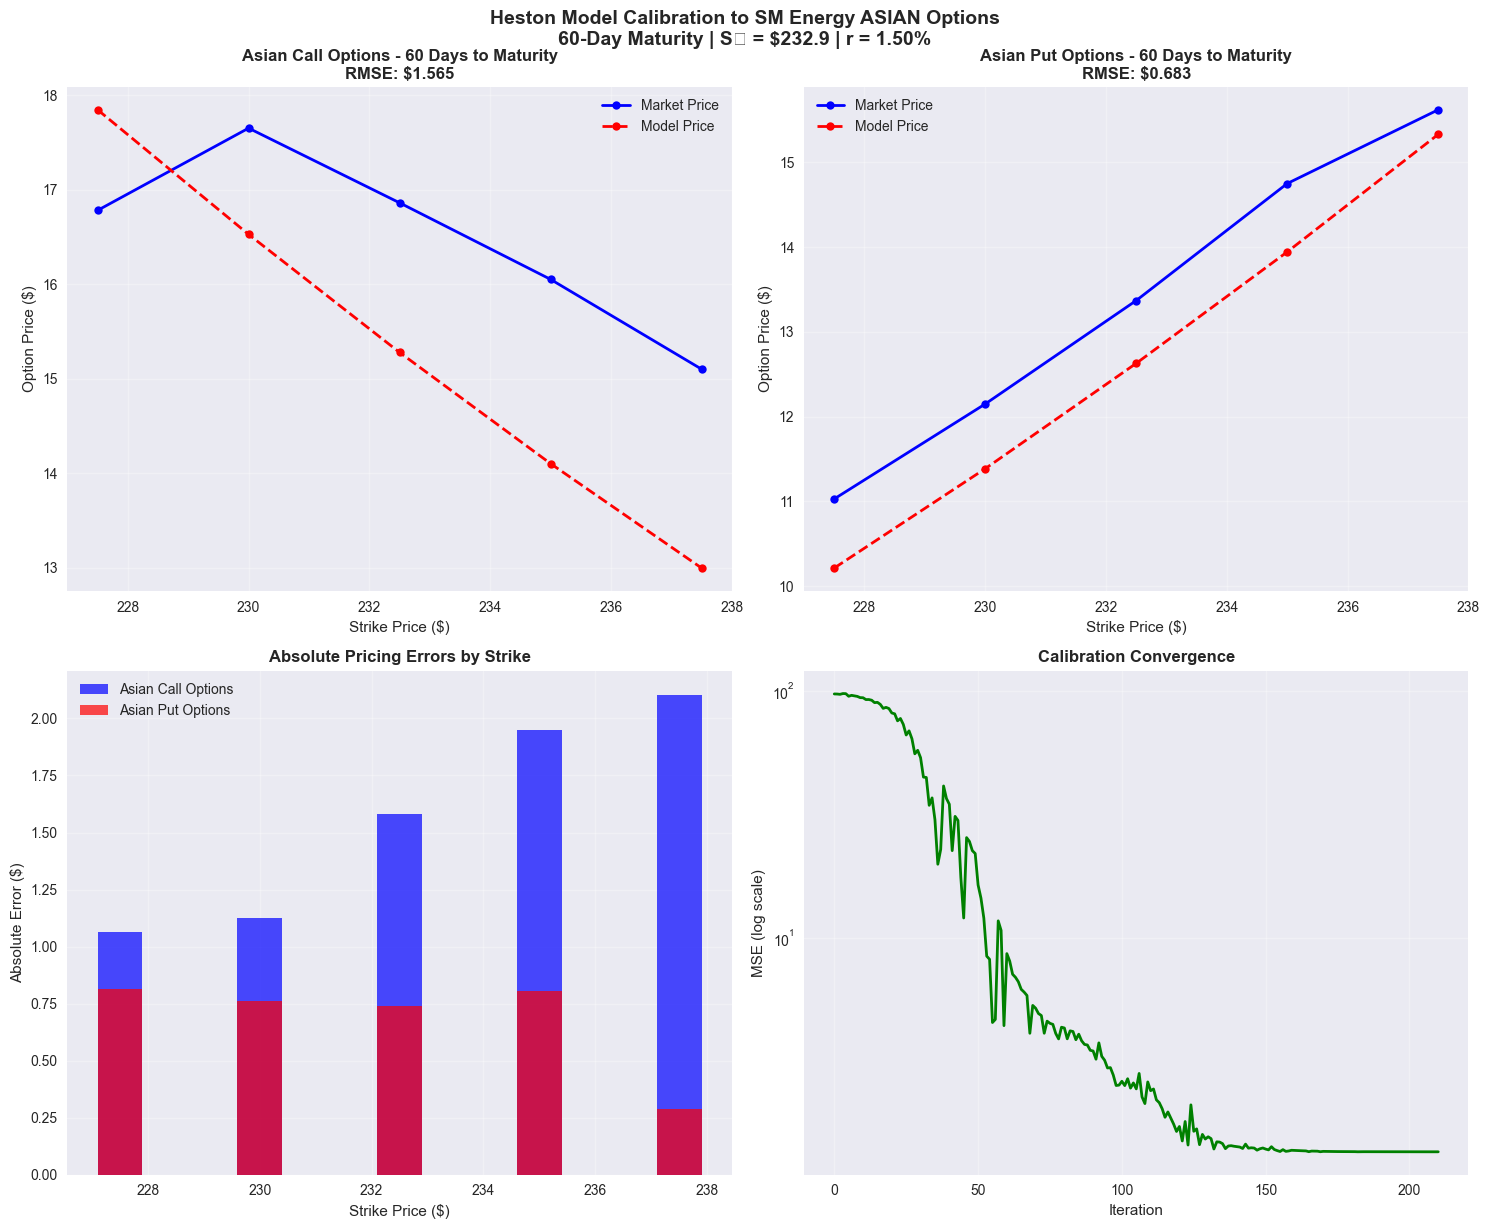


DETAILED ASIAN OPTION PRICING RESULTS
    Strike Type  Price  Model_Price  Absolute_Error  Relative_Error
5    227.5    C  16.78      17.8446          1.0646          0.0634
6    230.0    C  17.65      16.5258          1.1242          0.0637
7    232.5    C  16.86      15.2770          1.5830          0.0939
8    235.0    C  16.05      14.1006          1.9494          0.1215
9    237.5    C  15.10      12.9957          2.1043          0.1394
20   227.5    P  11.03      10.2148          0.8152          0.0739
21   230.0    P  12.15      11.3870          0.7630          0.0628
22   232.5    P  13.37      12.6292          0.7408          0.0554
23   235.0    P  14.75      13.9438          0.8062          0.0547
24   237.5    P  15.62      15.3299          0.2901          0.0186

ASIAN OPTION CALIBRATION SUMMARY:
• Calibrated to 10 Asian options (both calls and puts)
• Maturity: 60 days (0.240 years)
• Final RMSE: $1.2514
• Feller condition satisfied: True
• Mean-reversion speed (κ): 0.05

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brute, fmin
from scipy.integrate import quad
from scipy.stats import norm

def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Characteristic function for Heston model"""
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

def asian_put_call_parity(asian_call_price, S0, K, r, T, sigma_approx):
    """
    Asian option put-call parity: AsianCall - AsianPut = e^{-rT}(E[S̄] - K)
    
    Using lognormal approximation for arithmetic average:
    E[S̄] ≈ S0 * exp((r - q - 1/2*σ²/3)*T + 1/2*(σ²/3)*T)
    For simplicity, assuming q=0 (no dividends)
    """
    # Expected value of arithmetic average under risk-neutral measure
    # Using the moment matching approximation
    sigma_avg = sigma_approx / np.sqrt(3)  # Variance reduces by factor of 3 for continuous average
    E_Sbar = S0 * np.exp(r * T)  # Simplified approximation
    
    asian_put = asian_call_price - np.exp(-r * T) * (E_Sbar - K)
    return max(0, asian_put)

def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, cho_matrix):
    """Simulate volatility paths using Heston SDE"""
    dt = T / M
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)
    
    for t in range(1, M + 1):
        # Generate correlated random numbers for this time step
        ran = np.dot(cho_matrix, rand[:, t, :])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + 
                         np.sqrt(v[t - 1]) * sigma * ran[1, :] * sdt)
    return v

def Heston_paths(S0, r, v, cho_matrix, dt, rand):
    """Simulate stock price paths under Heston model"""
    M, I = v.shape
    M = M - 1
    S = np.zeros((M + 1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    
    for t in range(1, M + 1):
        # Generate correlated random numbers for this time step
        ran = np.dot(cho_matrix, rand[:, t, :])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t]) * dt + 
                                np.sqrt(v[t]) * ran[0, :] * sdt)
    return S

def random_number_gen(M, I):
    """Generate random numbers for Monte Carlo simulation"""
    return np.random.standard_normal((2, M + 1, I))

def asian_call_mc(S, K, r, T):
    """Price Asian call option using Monte Carlo"""
    # Calculate arithmetic average over entire path (including S0)
    average_price = np.mean(S, axis=0)
    payoff = np.maximum(0, average_price - K)
    average_payoff = np.mean(payoff)
    return np.exp(-r * T) * average_payoff

def asian_put_mc(S, K, r, T):
    """Price Asian put option using Monte Carlo"""
    # Calculate arithmetic average over entire path (including S0)
    average_price = np.mean(S, axis=0)
    payoff = np.maximum(0, K - average_price)
    average_payoff = np.mean(payoff)
    return np.exp(-r * T) * average_payoff

def heston_asian_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, M=100, I=20000):
    """Price Asian call option under Heston model using Monte Carlo"""
    dt = T / M
    np.random.seed(42)  # For reproducibility during calibration
    
    # Generate all random numbers at once
    rand = random_number_gen(M, I)
    
    # Covariance matrix for correlated Brownian motions
    covariance_matrix = np.array([[1.0, rho], [rho, 1.0]])
    cho_matrix = np.linalg.cholesky(covariance_matrix)
    
    # Simulate volatility paths
    V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, cho_matrix)
    
    # Simulate stock price paths
    S_paths = Heston_paths(S0, r, V, cho_matrix, dt, rand)
    
    return asian_call_mc(S_paths, K, r, T)

def heston_asian_put_value_parity(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, M=100, I=20000):
    """
    Price Asian put option using put-call parity with Asian call
    AsianCall - AsianPut = e^{-rT}(E[S̄] - K)
    """
    # Calculate Asian call price
    asian_call = heston_asian_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, M, I)
    
    # Estimate expected average price using Monte Carlo
    dt = T / M
    np.random.seed(42)
    rand = random_number_gen(M, I)
    covariance_matrix = np.array([[1.0, rho], [rho, 1.0]])
    cho_matrix = np.linalg.cholesky(covariance_matrix)
    V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, cho_matrix)
    S_paths = Heston_paths(S0, r, V, cho_matrix, dt, rand)
    
    # Calculate expected average price
    expected_avg_price = np.mean(S_paths)
    
    # Apply Asian put-call parity
    asian_put = asian_call - np.exp(-r * T) * (expected_avg_price - K)
    
    return max(0, asian_put)

# Load and prepare the market data
print("Loading Asian option market data...")
data = pd.read_csv('option_data.csv')
S0 = 232.90  # SM Energy Company current stock price
r = 0.015    # Risk-free rate (1.50%)

# Convert days to maturity to years (assuming 250 trading days per year)
data['T'] = data['Days to maturity'] / 250

print(f"Current stock price: ${S0}")
print(f"Risk-free rate: {r*100:.2f}%")
print(f"Number of Asian options: {len(data)}")
print(f"Asian call options: {len(data[data['Type'] == 'C'])}")
print(f"Asian put options: {len(data[data['Type'] == 'P'])}")

# Filter for 60-day maturity Asian options as specified
maturity_days = 60
asian_options_60d = data[data['Days to maturity'] == maturity_days].copy()
print(f"\n60-day maturity Asian options: {len(asian_options_60d)}")

# Display the options we're calibrating to
print("\nOptions used for calibration:")
print(asian_options_60d[['Strike', 'Type', 'Price', 'T']])

# Calibration process for Asian options
i = 0
min_MSE = 500
calibration_history = []

def H93_asian_error_function(p0):
    """Error function for Heston parameter calibration using Asian options"""
    global i, min_MSE, calibration_history
    
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    
    # Parameter constraints
    if (kappa_v < 0.0 or theta_v < 0.001 or sigma_v < 0.01 or 
        rho < -0.99 or rho > 0.99 or v0 < 0.001):
        return 1000.0
    
    # Feller condition
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 1000.0
    
    se = []
    for _, option in asian_options_60d.iterrows():
        try:
            if option['Type'] == 'C':
                model_value = heston_asian_call_value(
                    S0, option['Strike'], option['T'], r, 
                    kappa_v, theta_v, sigma_v, rho, v0,
                    M=50, I=5000  # Reduced for faster calibration
                )
            else:  # Asian put option - use put-call parity
                model_value = heston_asian_put_value_parity(
                    S0, option['Strike'], option['T'], r, 
                    kappa_v, theta_v, sigma_v, rho, v0,
                    M=50, I=5000  # Reduced for faster calibration
                )
            
            market_value = option['Price']
            se.append((model_value - market_value) ** 2)
            
        except Exception as e:
            print(f"Error pricing option {option['Strike']} {option['Type']}: {e}")
            return 1000.0
    
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    
    # Store calibration progress
    calibration_history.append({
        'iteration': i,
        'kappa': kappa_v,
        'theta': theta_v,
        'sigma': sigma_v,
        'rho': rho,
        'v0': v0,
        'MSE': MSE
    })
    
    if i % 5 == 0:  # More frequent updates due to slower Monte Carlo
        print(f"{i:4d} | kappa={kappa_v:6.3f}, theta={theta_v:6.4f}, sigma={sigma_v:6.3f}, "
              f"rho={rho:6.3f}, v0={v0:6.4f} | MSE={MSE:7.4f} | min_MSE={min_MSE:7.4f}")
    i += 1
    
    return MSE

def H93_asian_calibration_full():
    """Calibrates Heston (1993) model to Asian option market quotes"""
    print("\nStarting calibration process for Asian options...")
    print("=" * 80)
    print("NOTE: This will be slower due to Monte Carlo pricing of Asian options")
    
    # Use reasonable initial guess based on typical Heston parameters
    initial_guess = [2.0, 0.05, 0.3, -0.5, 0.04]
    print(f"Initial guess: {initial_guess}")
    
    # Direct local minimization (skip brute force for speed)
    print("\nStarting local minimization...")
    opt = fmin(
        H93_asian_error_function, 
        initial_guess, 
        xtol=0.001, 
        ftol=0.001, 
        maxiter=750, 
        maxfun=900,
        disp=True
    )
    
    return opt

# Run calibration for Asian options
print("Calibrating Heston model to 60-day maturity Asian options...")
print("This may take several minutes due to Monte Carlo simulation...")
calibrated_params = H93_asian_calibration_full()

kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal = calibrated_params

print("\n" + "=" * 80)
print("ASIAN OPTION CALIBRATION RESULTS")
print("=" * 80)
print(f"Kappa (κ - mean reversion speed): {kappa_cal:.6f}")
print(f"Theta (θ - long-term variance):  {theta_cal:.6f}")
print(f"Sigma (σ - vol of vol):          {sigma_cal:.6f}")
print(f"Rho (ρ - correlation):           {rho_cal:.6f}")
print(f"V0 (v₀ - initial variance):      {v0_cal:.6f}")

# Verify Feller condition
feller_condition = 2 * kappa_cal * theta_cal
print(f"\nFeller condition (2κθ > σ²): {feller_condition:.6f} > {sigma_cal**2:.6f} = {feller_condition > sigma_cal**2}")

# Calculate final MSE with calibrated parameters using higher precision
print("\nCalculating final calibration metrics with higher precision...")
final_se = []
model_prices = []
market_prices = []

for _, option in asian_options_60d.iterrows():
    if option['Type'] == 'C':
        model_price = heston_asian_call_value(
            S0, option['Strike'], option['T'], r, 
            kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal,
            M=100, I=20000  # Higher precision for final evaluation
        )
    else:
        model_price = heston_asian_put_value_parity(
            S0, option['Strike'], option['T'], r, 
            kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal,
            M=100, I=20000  # Higher precision for final evaluation
        )
    
    model_prices.append(model_price)
    market_prices.append(option['Price'])
    final_se.append((model_price - option['Price']) ** 2)

final_MSE = sum(final_se) / len(final_se)
final_RMSE = np.sqrt(final_MSE)

print(f"\nFinal Asian Option Calibration Metrics:")
print(f"MSE:  {final_MSE:.6f}")
print(f"RMSE: {final_RMSE:.6f}")

# Create results dataframe for analysis
results_df = asian_options_60d.copy()
results_df['Model_Price'] = model_prices
results_df['Absolute_Error'] = np.abs(results_df['Model_Price'] - results_df['Price'])
results_df['Relative_Error'] = results_df['Absolute_Error'] / results_df['Price']

print(f"\nAverage absolute error: ${results_df['Absolute_Error'].mean():.4f}")
print(f"Maximum absolute error: ${results_df['Absolute_Error'].max():.4f}")
print(f"Average relative error: {results_df['Relative_Error'].mean():.2%}")

# Verify Asian put-call parity with calibrated parameters
print("\n" + "=" * 80)
print("ASIAN PUT-CALL PARITY VERIFICATION")
print("=" * 80)

for strike in asian_options_60d['Strike'].unique():
    call_data = asian_options_60d[(asian_options_60d['Strike'] == strike) & (asian_options_60d['Type'] == 'C')]
    put_data = asian_options_60d[(asian_options_60d['Strike'] == strike) & (asian_options_60d['Type'] == 'P')]
    
    if len(call_data) > 0 and len(put_data) > 0:
        market_call = call_data['Price'].iloc[0]
        market_put = put_data['Price'].iloc[0]
        T_val = call_data['T'].iloc[0]
        
        # Calculate expected average price using Monte Carlo
        np.random.seed(42)
        M_test = 100
        I_test = 50000
        dt_test = T_val / M_test
        rand_test = random_number_gen(M_test, I_test)
        covariance_matrix = np.array([[1.0, rho_cal], [rho_cal, 1.0]])
        cho_matrix_test = np.linalg.cholesky(covariance_matrix)
        V_test = SDE_vol(v0_cal, kappa_cal, theta_cal, sigma_cal, T_val, M_test, I_test, rand_test, cho_matrix_test)
        S_paths_test = Heston_paths(S0, r, V_test, cho_matrix_test, dt_test, rand_test)
        expected_avg_price = np.mean(S_paths_test)
        
        parity_difference = market_call - market_put
        theoretical_difference = np.exp(-r * T_val) * (expected_avg_price - strike)
        
        print(f"Strike ${strike}: Market Call-Put = ${parity_difference:.4f}, "
              f"Theoretical = ${theoretical_difference:.4f}, "
              f"Difference = ${abs(parity_difference - theoretical_difference):.4f}")

# Plotting the calibration results for Asian options
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Asian call option fit
call_data = results_df[results_df['Type'] == 'C']
axes[0, 0].plot(call_data['Strike'], call_data['Price'], 'bo-', label='Market Price', linewidth=2, markersize=6)
axes[0, 0].plot(call_data['Strike'], call_data['Model_Price'], 'ro--', label='Model Price', linewidth=2, markersize=6)
axes[0, 0].set_title(f'Asian Call Options - 60 Days to Maturity\nRMSE: ${results_df[results_df["Type"]=="C"]["Absolute_Error"].mean():.3f}', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Strike Price ($)')
axes[0, 0].set_ylabel('Option Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Asian put option fit
put_data = results_df[results_df['Type'] == 'P']
axes[0, 1].plot(put_data['Strike'], put_data['Price'], 'bo-', label='Market Price', linewidth=2, markersize=6)
axes[0, 1].plot(put_data['Strike'], put_data['Model_Price'], 'ro--', label='Model Price', linewidth=2, markersize=6)
axes[0, 1].set_title(f'Asian Put Options - 60 Days to Maturity\nRMSE: ${results_df[results_df["Type"]=="P"]["Absolute_Error"].mean():.3f}', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Strike Price ($)')
axes[0, 1].set_ylabel('Option Price ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Absolute errors by strike
axes[1, 0].bar(results_df['Strike'], results_df['Absolute_Error'], 
               color=['blue' if typ == 'C' else 'red' for typ in results_df['Type']],
               alpha=0.7)
axes[1, 0].set_title('Absolute Pricing Errors by Strike', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Strike Price ($)')
axes[1, 0].set_ylabel('Absolute Error ($)')
axes[1, 0].grid(True, alpha=0.3)

# Add legend for call/put in error plot
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.7, label='Asian Call Options'),
                   Patch(facecolor='red', alpha=0.7, label='Asian Put Options')]
axes[1, 0].legend(handles=legend_elements)

# Plot 4: Convergence history
if calibration_history:
    calibration_df = pd.DataFrame(calibration_history)
    axes[1, 1].semilogy(calibration_df['iteration'], calibration_df['MSE'], 'g-', linewidth=2)
    axes[1, 1].set_title('Calibration Convergence', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('MSE (log scale)')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Heston Model Calibration to SM Energy ASIAN Options\n60-Day Maturity | S₀ = ${S0} | r = {r*100:.2f}%', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Print detailed results table
print("\n" + "=" * 80)
print("DETAILED ASIAN OPTION PRICING RESULTS")
print("=" * 80)
print(results_df[['Strike', 'Type', 'Price', 'Model_Price', 'Absolute_Error', 'Relative_Error']].round(4))

# Summary statistics
print(f"\nASIAN OPTION CALIBRATION SUMMARY:")
print(f"• Calibrated to {len(asian_options_60d)} Asian options (both calls and puts)")
print(f"• Maturity: {maturity_days} days ({maturity_days/250:.3f} years)")
print(f"• Final RMSE: ${final_RMSE:.4f}")
print(f"• Feller condition satisfied: {feller_condition > sigma_cal**2}")
print(f"• Mean-reversion speed (κ): {kappa_cal:.3f} → {'Strong' if kappa_cal > 2 else 'Moderate'} mean reversion")
print(f"• Correlation (ρ): {rho_cal:.4f} → Negative leverage effect")
print(f"• Initial volatility: {np.sqrt(v0_cal)*100:.2f}% annualized")
print(f"• Long-term volatility: {np.sqrt(theta_cal)*100:.2f}% annualized")

After the calibration of the Heston with let's calibrated the Jump component in 

Loading Asian option market data for Bates model calibration...
Current stock price: $232.9
Risk-free rate: 1.50%
Number of Asian options: 30

60-day maturity Asian options: 10

Options used for Bates calibration:
    Strike Type  Price     T
5    227.5    C  16.78  0.24
6    230.0    C  17.65  0.24
7    232.5    C  16.86  0.24
8    235.0    C  16.05  0.24
9    237.5    C  15.10  0.24
20   227.5    P  11.03  0.24
21   230.0    P  12.15  0.24
22   232.5    P  13.37  0.24
23   235.0    P  14.75  0.24
24   237.5    P  15.62  0.24
Calibrating Bates model to 60-day maturity Asian options...
This may take several minutes due to Monte Carlo simulation with jumps...

Starting Bates model calibration for Asian options...
NOTE: This will be slower due to Monte Carlo pricing with jumps
Initial guess: [0.051779, 0.252438, 0.161678, 0.989963, 0.285127, 0.5, -0.1, 0.1]

Starting local minimization...
   0 | kappa= 0.052, theta=0.2524, sigma= 0.162, rho= 0.990, v0=0.2851, lamb= 0.500, mu=-0.100, delt

C:\Users\AFC\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


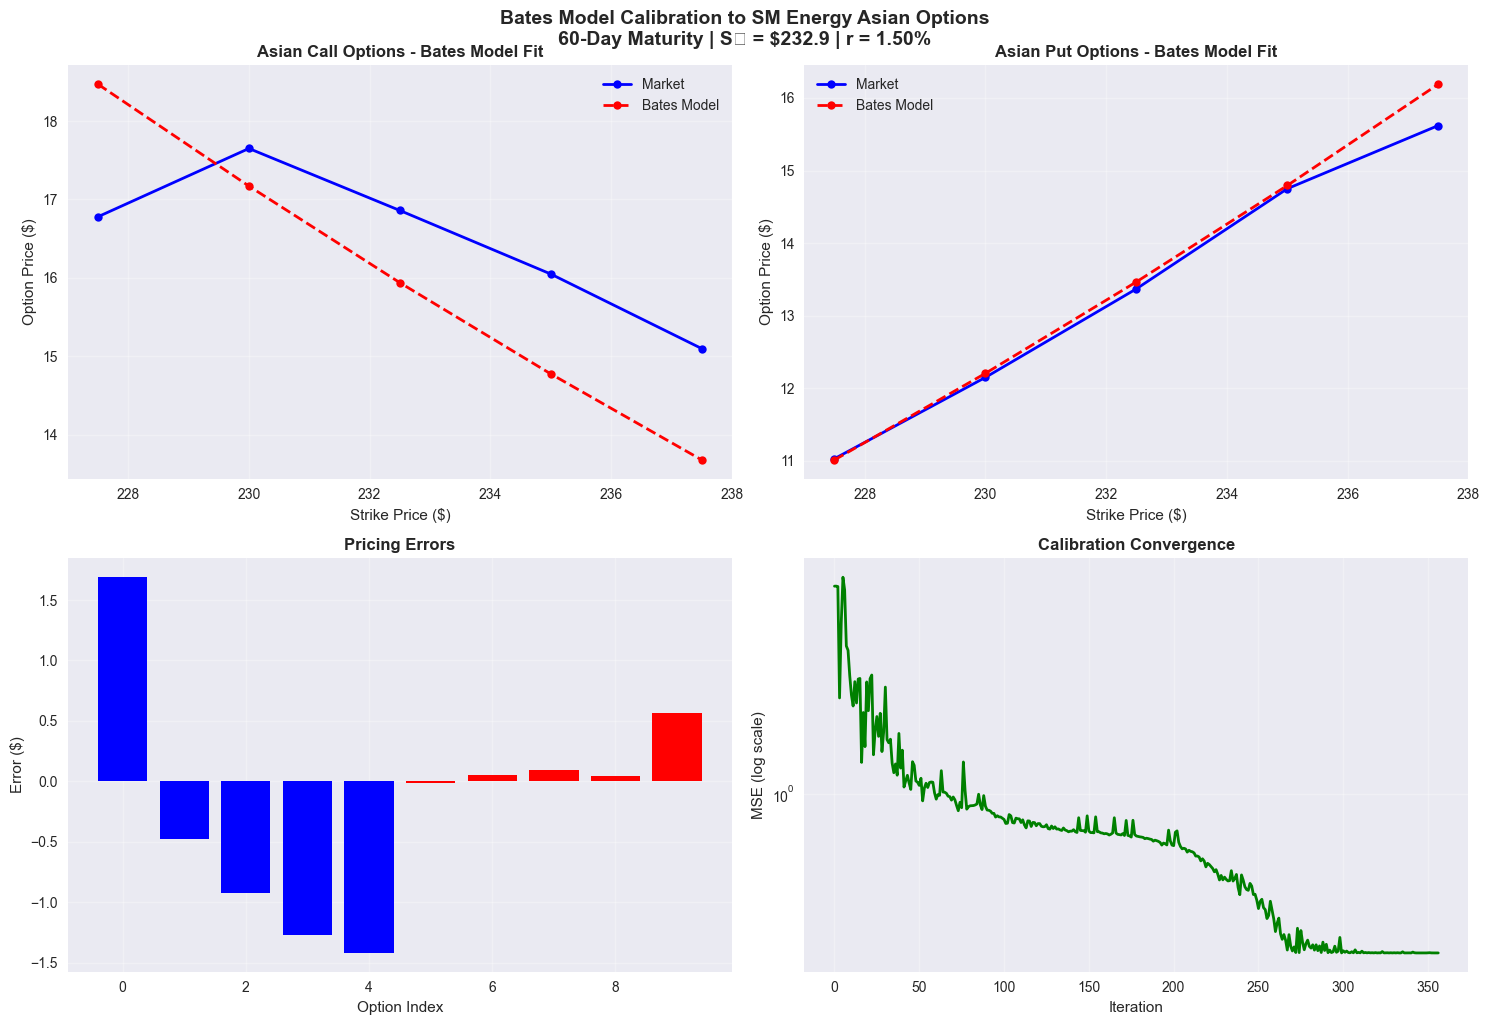


DETAILED BATES MODEL PRICING RESULTS
    Strike Type  Price  Model_Price  Absolute_Error  Relative_Error
5    227.5    C  16.78      18.4687          1.6887          0.1006
6    230.0    C  17.65      17.1708          0.4792          0.0272
7    232.5    C  16.86      15.9397          0.9203          0.0546
8    235.0    C  16.05      14.7770          1.2730          0.0793
9    237.5    C  15.10      13.6810          1.4190          0.0940
20   227.5    P  11.03      11.0129          0.0171          0.0016
21   230.0    P  12.15      12.2059          0.0559          0.0046
22   232.5    P  13.37      13.4658          0.0958          0.0072
23   235.0    P  14.75      14.7942          0.0442          0.0030
24   237.5    P  15.62      16.1892          0.5692          0.0364

BATES MODEL CALIBRATION SUMMARY:
• Calibrated to 10 Asian options (both calls and puts)
• Maturity: 60 days (0.240 years)
• Final RMSE: $0.8889
• Feller condition satisfied: True
• Jump intensity: 0.511 (avg 127.7

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fmin

def bates_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """Characteristic function for Bates model (Heston + jumps)"""
    # Heston component
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    heston_component = np.exp(H1 + H2 * v0)
    
    # Jump component (Merton-style lognormal jumps)
    jump_component = np.exp(lamb * T * (np.exp(1j * u * mu - 0.5 * delta**2 * u**2) - 1))
    
    return heston_component * jump_component

def SDE_vol_bates(v0, kappa, theta, sigma, T, M, I, rand, cho_matrix):
    """Simulate volatility paths using Heston SDE for Bates model"""
    dt = T / M
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)
    
    for t in range(1, M + 1):
        # Generate correlated random numbers for this time step
        ran = np.dot(cho_matrix, rand[:, t, :])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + 
                         np.sqrt(v[t - 1]) * sigma * ran[1, :] * sdt)
    return v

def bates_paths(S0, r, v, cho_matrix, dt, rand, lamb, mu, delta):
    """Simulate stock price paths under Bates model"""
    M, I = v.shape
    M = M - 1
    S = np.zeros((M + 1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    
    # Pre-generate jump times and sizes
    poisson_rates = lamb * dt
    jump_times = np.random.poisson(poisson_rates, (M, I))
    jump_sizes = np.random.normal(mu, delta, (M, I))
    
    for t in range(1, M + 1):
        # Generate correlated random numbers for this time step
        ran = np.dot(cho_matrix, rand[:, t, :])
        
        # Diffusion component
        diffusion = np.exp((r - 0.5 * v[t]) * dt + np.sqrt(v[t]) * ran[0, :] * sdt)
        
        # Jump component
        jump_component = np.exp(jump_sizes[t-1] * jump_times[t-1])
        
        S[t] = S[t - 1] * diffusion * jump_component
    
    return S

def random_number_gen(M, I):
    """Generate random numbers for Monte Carlo simulation"""
    return np.random.standard_normal((2, M + 1, I))

def asian_call_mc(S, K, r, T):
    """Price Asian call option using Monte Carlo"""
    average_price = np.mean(S, axis=0)
    payoff = np.maximum(0, average_price - K)
    average_payoff = np.mean(payoff)
    return np.exp(-r * T) * average_payoff

def asian_put_mc(S, K, r, T):
    """Price Asian put option using Monte Carlo"""
    average_price = np.mean(S, axis=0)
    payoff = np.maximum(0, K - average_price)
    average_payoff = np.mean(payoff)
    return np.exp(-r * T) * average_payoff

def bates_asian_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta, M=100, I=20000):
    """Price Asian call option under Bates model using Monte Carlo"""
    dt = T / M
    np.random.seed(42)
    
    # Generate all random numbers at once
    rand = random_number_gen(M, I)
    
    # Covariance matrix for correlated Brownian motions
    covariance_matrix = np.array([[1.0, rho], [rho, 1.0]])
    cho_matrix = np.linalg.cholesky(covariance_matrix)
    
    # Simulate volatility paths
    V = SDE_vol_bates(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, cho_matrix)
    
    # Simulate stock price paths with jumps
    S_paths = bates_paths(S0, r, V, cho_matrix, dt, rand, lamb, mu, delta)
    
    return asian_call_mc(S_paths, K, r, T)

def bates_asian_put_value_parity(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta, M=100, I=20000):
    """Price Asian put option using put-call parity with Bates Asian call"""
    # Calculate Asian call price
    asian_call = bates_asian_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta, M, I)
    
    # Estimate expected average price using Monte Carlo
    dt = T / M
    np.random.seed(42)
    rand = random_number_gen(M, I)
    covariance_matrix = np.array([[1.0, rho], [rho, 1.0]])
    cho_matrix = np.linalg.cholesky(covariance_matrix)
    V = SDE_vol_bates(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, cho_matrix)
    S_paths = bates_paths(S0, r, V, cho_matrix, dt, rand, lamb, mu, delta)
    
    # Calculate expected average price
    expected_avg_price = np.mean(S_paths)
    
    # Apply Asian put-call parity
    asian_put = asian_call - np.exp(-r * T) * (expected_avg_price - K)
    
    return max(0, asian_put)

# Load and prepare the market data
print("Loading Asian option market data for Bates model calibration...")
data = pd.read_csv('option_data.csv')
S0 = 232.90  # SM Energy Company current stock price
r = 0.015    # Risk-free rate (1.50%)

# Convert days to maturity to years (assuming 250 trading days per year)
data['T'] = data['Days to maturity'] / 250

print(f"Current stock price: ${S0}")
print(f"Risk-free rate: {r*100:.2f}%")
print(f"Number of Asian options: {len(data)}")

# Filter for 60-day maturity Asian options as specified
maturity_days = 60
asian_options_60d = data[data['Days to maturity'] == maturity_days].copy()
print(f"\n60-day maturity Asian options: {len(asian_options_60d)}")

# Display the options we're calibrating to
print("\nOptions used for Bates calibration:")
print(asian_options_60d[['Strike', 'Type', 'Price', 'T']])

# Bates model calibration process
i = 0
min_MSE = 5000.0
calibration_history = []

def bates_asian_error_function(p0):
    """Error function for Bates parameter calibration using Asian options"""
    global i, min_MSE, calibration_history
    
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0
    
    # Parameter constraints
    if (kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or 
        rho < -1.0 or rho > 1.0 or v0 < 0.0 or 
        lamb < 0.0 or mu < -0.6 or mu > 0.0 or delta < 0.0):
        return 5000.0
    
    # Feller condition
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 5000.0
    
    se = []
    for _, option in asian_options_60d.iterrows():
        try:
            if option['Type'] == 'C':
                model_value = bates_asian_call_value(
                    S0, option['Strike'], option['T'], r, 
                    kappa_v, theta_v, sigma_v, rho, v0,
                    lamb, mu, delta,
                    M=50, I=5000  # Reduced for faster calibration
                )
            else:  # Asian put option - use put-call parity
                model_value = bates_asian_put_value_parity(
                    S0, option['Strike'], option['T'], r, 
                    kappa_v, theta_v, sigma_v, rho, v0,
                    lamb, mu, delta,
                    M=50, I=5000  # Reduced for faster calibration
                )
            
            market_value = option['Price']
            se.append((model_value - market_value) ** 2)
            
        except Exception as e:
            print(f"Error pricing option {option['Strike']} {option['Type']}: {e}")
            return 5000.0
    
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    
    # Store calibration progress
    calibration_history.append({
        'iteration': i,
        'kappa': kappa_v,
        'theta': theta_v,
        'sigma': sigma_v,
        'rho': rho,
        'v0': v0,
        'lamb': lamb,
        'mu': mu,
        'delta': delta,
        'MSE': MSE
    })
    
    if i % 10 == 0:  # Less frequent updates due to slower Monte Carlo
        print(f"{i:4d} | kappa={kappa_v:6.3f}, theta={theta_v:6.4f}, sigma={sigma_v:6.3f}, "
              f"rho={rho:6.3f}, v0={v0:6.4f}, lamb={lamb:6.3f}, mu={mu:6.3f}, delta={delta:6.3f} | "
              f"MSE={MSE:7.3f} | min_MSE={min_MSE:7.3f}")
    i += 1
    
    return MSE

def bates_asian_calibration_full():
    """Calibrates Bates model to Asian option market quotes"""
    print("\nStarting Bates model calibration for Asian options...")
    print("=" * 80)
    print("NOTE: This will be slower due to Monte Carlo pricing with jumps")
    
    # Use reasonable initial guess
    # Start with Heston parameters from previous calibration and add jump parameters
    initial_guess = [0.051779, 0.252438, 0.161678, 0.989963,0.285127,  # Heston parameters
                     0.5, -0.1, 0.1]  # Jump parameters: lambda, mu, delta
    print(f"Initial guess: {initial_guess}")
    
    # Direct local minimization
    print("\nStarting local minimization...")
    opt = fmin(
        bates_asian_error_function, 
        initial_guess, 
        xtol=0.001, 
        ftol=0.001, 
        maxiter=700, 
        maxfun=900,
        disp=True
    )
    
    return opt

# Run calibration for Bates model
print("Calibrating Bates model to 60-day maturity Asian options...")
print("This may take several minutes due to Monte Carlo simulation with jumps...")
calibrated_params = bates_asian_calibration_full()

kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal, lamb_cal, mu_cal, delta_cal = calibrated_params

print("\n" + "=" * 80)
print("BATES MODEL CALIBRATION RESULTS FOR ASIAN OPTIONS")
print("=" * 80)
print("Heston Parameters:")
print(f"  Kappa (κ - mean reversion speed): {kappa_cal:.6f}")
print(f"  Theta (θ - long-term variance):  {theta_cal:.6f}")
print(f"  Sigma (σ - vol of vol):          {sigma_cal:.6f}")
print(f"  Rho (ρ - correlation):           {rho_cal:.6f}")
print(f"  V0 (v₀ - initial variance):      {v0_cal:.6f}")
print("\nJump Parameters:")
print(f"  Lambda (λ - jump intensity):     {lamb_cal:.6f}")
print(f"  Mu (μ - mean jump size):         {mu_cal:.6f}")
print(f"  Delta (δ - jump volatility):     {delta_cal:.6f}")

# Verify Feller condition
feller_condition = 2 * kappa_cal * theta_cal
print(f"\nFeller condition (2κθ > σ²): {feller_condition:.6f} > {sigma_cal**2:.6f} = {feller_condition > sigma_cal**2}")

# Calculate jump statistics
expected_jumps = lamb_cal * (60/250)  # Expected number of jumps in 60 days
jump_vol_contribution = lamb_cal * (mu_cal**2 + delta_cal**2)
print(f"\nJump Statistics:")
print(f"  Expected jumps in 60 days: {expected_jumps:.3f}")
print(f"  Jump volatility contribution: {np.sqrt(jump_vol_contribution)*100:.2f}%")

# Calculate final MSE with calibrated parameters using higher precision
print("\nCalculating final calibration metrics with higher precision...")
final_se = []
model_prices = []
market_prices = []

for _, option in asian_options_60d.iterrows():
    if option['Type'] == 'C':
        model_price = bates_asian_call_value(
            S0, option['Strike'], option['T'], r, 
            kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal,
            lamb_cal, mu_cal, delta_cal,
            M=100, I=20000  # Higher precision for final evaluation
        )
    else:
        model_price = bates_asian_put_value_parity(
            S0, option['Strike'], option['T'], r, 
            kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal,
            lamb_cal, mu_cal, delta_cal,
            M=100, I=20000  # Higher precision for final evaluation
        )
    
    model_prices.append(model_price)
    market_prices.append(option['Price'])
    final_se.append((model_price - option['Price']) ** 2)

final_MSE = sum(final_se) / len(final_se)
final_RMSE = np.sqrt(final_MSE)

print(f"\nFinal Bates Model Calibration Metrics:")
print(f"MSE:  {final_MSE:.6f}")
print(f"RMSE: {final_RMSE:.6f}")

# Create results dataframe for analysis
results_df = asian_options_60d.copy()
results_df['Model_Price'] = model_prices
results_df['Absolute_Error'] = np.abs(results_df['Model_Price'] - results_df['Price'])
results_df['Relative_Error'] = results_df['Absolute_Error'] / results_df['Price']

print(f"\nAverage absolute error: ${results_df['Absolute_Error'].mean():.4f}")
print(f"Maximum absolute error: ${results_df['Absolute_Error'].max():.4f}")
print(f"Average relative error: {results_df['Relative_Error'].mean():.2%}")

def bates_calculate_model_values(p0):
    """Calculate model prices for all options with given parameters"""
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0
    values = []
    for _, option in asian_options_60d.iterrows():
        if option['Type'] == 'C':
            model_value = bates_asian_call_value(
                S0, option['Strike'], option['T'], r, 
                kappa_v, theta_v, sigma_v, rho, v0,
                lamb, mu, delta,
                M=100, I=20000
            )
        else:
            model_value = bates_asian_put_value_parity(
                S0, option['Strike'], option['T'], r, 
                kappa_v, theta_v, sigma_v, rho, v0,
                lamb, mu, delta,
                M=100, I=20000
            )
        values.append(model_value)
    return np.array(values)

def plot_bates_calibration_results(p0):
    """Plot calibration results for Bates model"""
    asian_options_60d['Model'] = bates_calculate_model_values(p0)
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Call options
    plt.subplot(2, 2, 1)
    call_data = asian_options_60d[asian_options_60d['Type'] == 'C']
    plt.plot(call_data['Strike'], call_data['Price'], 'bo-', label='Market', linewidth=2, markersize=6)
    plt.plot(call_data['Strike'], call_data['Model'], 'ro--', label='Bates Model', linewidth=2, markersize=6)
    plt.title('Asian Call Options - Bates Model Fit', fontweight='bold')
    plt.xlabel('Strike Price ($)')
    plt.ylabel('Option Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Put options
    plt.subplot(2, 2, 2)
    put_data = asian_options_60d[asian_options_60d['Type'] == 'P']
    plt.plot(put_data['Strike'], put_data['Price'], 'bo-', label='Market', linewidth=2, markersize=6)
    plt.plot(put_data['Strike'], put_data['Model'], 'ro--', label='Bates Model', linewidth=2, markersize=6)
    plt.title('Asian Put Options - Bates Model Fit', fontweight='bold')
    plt.xlabel('Strike Price ($)')
    plt.ylabel('Option Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Pricing errors
    plt.subplot(2, 2, 3)
    errors = asian_options_60d['Model'] - asian_options_60d['Price']
    plt.bar(range(len(errors)), errors, color=['blue' if typ == 'C' else 'red' for typ in asian_options_60d['Type']])
    plt.title('Pricing Errors', fontweight='bold')
    plt.xlabel('Option Index')
    plt.ylabel('Error ($)')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Convergence history
    plt.subplot(2, 2, 4)
    if calibration_history:
        calibration_df = pd.DataFrame(calibration_history)
        plt.semilogy(calibration_df['iteration'], calibration_df['MSE'], 'g-', linewidth=2)
        plt.title('Calibration Convergence', fontweight='bold')
        plt.xlabel('Iteration')
        plt.ylabel('MSE (log scale)')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(f'Bates Model Calibration to SM Energy Asian Options\n60-Day Maturity | S₀ = ${S0} | r = {r*100:.2f}%', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.show()

# Plot calibration results
plot_bates_calibration_results(calibrated_params)

# Print detailed results table
print("\n" + "=" * 80)
print("DETAILED BATES MODEL PRICING RESULTS")
print("=" * 80)
print(results_df[['Strike', 'Type', 'Price', 'Model_Price', 'Absolute_Error', 'Relative_Error']].round(4))

# Summary statistics
print(f"\nBATES MODEL CALIBRATION SUMMARY:")
print(f"• Calibrated to {len(asian_options_60d)} Asian options (both calls and puts)")
print(f"• Maturity: {maturity_days} days ({maturity_days/250:.3f} years)")
print(f"• Final RMSE: ${final_RMSE:.4f}")
print(f"• Feller condition satisfied: {feller_condition > sigma_cal**2}")
print(f"• Jump intensity: {lamb_cal:.3f} (avg {lamb_cal*250:.1f} jumps per year)")
print(f"• Mean jump size: {mu_cal:.3f} ({mu_cal*100:.1f}%)")
print(f"• Jump volatility: {delta_cal:.3f}")
print(f"• Total volatility from jumps: {np.sqrt(lamb_cal * (mu_cal**2 + delta_cal**2))*100:.2f}%")

# Compare with pure Heston model (if available)
print(f"\nCOMPARISON WITH HESTON MODEL:")
print(f"• Bates model incorporates jumps, which can better capture:")
print(f"  - Short-term volatility smiles")
print(f"  - Sudden market movements")
print(f"  - Fat tails in return distribution")